# Hồi quy tuyến tính bội

Lấy dữ liệu đã làm sạch:

In [1]:
gpu_clean <- read.csv("gpu_ready_for_models.csv")

Cài đặt thư viện

In [ ]:
install.packages("GGally")
install.packages("car")
install.packages("lmtest")
install.packages("leaps")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘patchwork’, ‘ggstats’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Mục tiêu của phần này là xây dựng một mô hình dự đoán Max_Power dựa trên dữ liệu đã làm sạch từ phần trước.

Bắt đầu bằng việc chọn lọc các biến để xây dựng mô hình, sau đó từng bước đánh giá, kiểm định các giả định về mô hình.

## 1. Xây dựng mô hình

Trước hết, mô hình sẽ bỏ qua các biến phân loại như `Manufacturer`, `Memory_Type` và `Notebook_GPU`.

In [3]:
cols_to_ignore = c("Manufacturer", "Memory_Type", "Notebook_GPU")
gpu_filter <- gpu_clean[, !(names(gpu_clean) %in% cols_to_ignore)]
names(gpu_filter)

[1] "Core_Speed"       "Max_Power"        "Memory"           "Memory_Bandwidth"
[5] "Memory_Speed"     "Memory_Bus"       "Process"          "ROPs"            
[9] "TMUs"

Ta sẽ đánh giá sơ bộ về dữ liệu dùng để dự báo, cụ thể cần để ý về mối quan hệ giữa biến mục tiêu với các biến dự báo, và giữa các biến dự báo với nhau. Ma trận sau đây có thể cho ta một cái nhìn tổng quát:

Loading required package: ggplot2



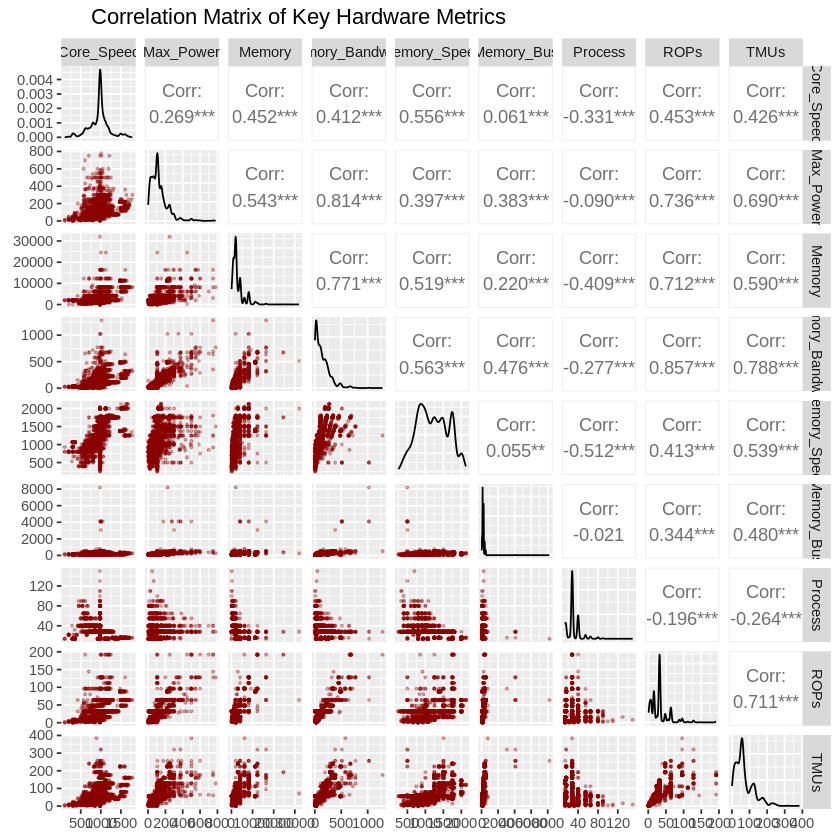

In [4]:
library(GGally)
p_pairs <- ggpairs(gpu_filter,
                   title = "     Correlation Matrix of Key Hardware Metrics",
                   lower = list(continuous = wrap("points", alpha = 0.3, size = 0.5, color = "darkred")))
p_pairs

Có thể thấy rằng:

Thứ nhất, quan hệ giữa Max_Power và các biến dự báo không tuyến tính một cách rõ ràng, thay vào đó các điểm dữ liệu có xu hướng toả rộng ra. Điều này gợi ý rằng một số giả định ban đầu về mô hình có thể bị vi phạm, ví dụ như tính tuyến tính, hoặc phân phối chuẩn của sai số.

Thứ hai, độ tương quan giữa Max_Power và các biến đều tương đối tốt, tuy nhiên độ tương quan giữa các biến với nhau cũng vậy, ví dụ như biến dự báo Memory_Bandwidth có tương quan khá cao với nhiều biến dự báo còn lại. Gợi ý rằng mô hình có thể gặp hiện tượng đa cộng tuyến.

Các phần sau sẽ phân tích sâu hơn và xử lý các yếu tố này. Bây giờ ta sẽ tiến hành chọn biến và xây dựng mô hình.

Ta bắt đầu bằng việc sử dụng quy trình chọn biến vét cạn - đánh giá tất cả các tổ hợp biến độc lập có thể có - để tìm ra mô hình tối ưu nhất. Hàm regsubsets() từ thư viện leaps có thể thực hiện điều này một cách dễ dàng:

In [231]:
library(leaps)
best_models <- summary(regsubsets(Max_Power ~ ., data = gpu_filter))
best_models$which


,(Intercept),Core_Speed,Memory,Memory_Bandwidth,Memory_Speed,Memory_Bus,Process,ROPs,TMUs
1,TRUE,FALSE,FALSE,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE
2,TRUE,FALSE,FALSE,TRUE,FALSE,FALSE,TRUE,FALSE,FALSE
3,TRUE,FALSE,TRUE,TRUE,FALSE,FALSE,TRUE,FALSE,FALSE
4,TRUE,FALSE,TRUE,TRUE,FALSE,FALSE,TRUE,FALSE,TRUE
5,TRUE,FALSE,TRUE,TRUE,FALSE,FALSE,TRUE,TRUE,TRUE
6,TRUE,FALSE,TRUE,TRUE,FALSE,TRUE,TRUE,TRUE,TRUE
7,TRUE,TRUE,TRUE,TRUE,FALSE,TRUE,TRUE,TRUE,TRUE
8,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE


Kết quả phía trên là các mô hình tối ưu nhất với mỗi kích thước mô hình có thể có, theo SSE của mô hình. Từ 8 mô hình phía trên, ta cần chọn ra mô hình tốt nhất, nhưng vẫn không quá phức tạp. Theo tiêu chí này, một thang đo phù hợp là hệ số xác định điều chỉnh.

Ta có thể sử dụng $adjr2 để quan sát hệ số xác định điều chỉnh của từng mô hình và dùng max.which() để xác định mô hình có kết quả tốt nhất.

In [232]:
best_models$adjr2
which.max(best_models$adjr2)

[1] 0.6632108 0.6829118 0.6916609 0.6984767 0.7034598 0.7065022 0.7103072
[8] 0.7103602

[1] 8

Vậy mô hình tốt nhất cũng chính là mô hình gồm đầy đủ biến. Từ mô hình này ta sẽ tiếp tục đánh giá mức độ đa cộng tuyến và kiểm định hệ số hồi quy.

In [233]:
base_model <- lm(Max_Power ~ ., data = gpu_filter)
base_model


Call:
lm(formula = Max_Power ~ ., data = gpu_filter)

Coefficients:
     (Intercept)        Core_Speed            Memory  Memory_Bandwidth  
       39.595009         -0.027187         -0.006362          0.571462  
    Memory_Speed        Memory_Bus           Process              ROPs  
       -0.004394         -0.030305          0.731992          0.521820  
            TMUs  
        0.306682  


Mức độ của hiện tượng đa cộng tuyến giữa các biến sẽ được đánh giá thông qua chỉ số VIF của từng biến độc lập, sử dụng lệnh vif() từ thư viện `car`:

In [234]:
library(car)
vif(base_model)

Core_Speed           Memory Memory_Bandwidth     Memory_Speed 
        1.686582         3.048072         8.022746         2.591191 
      Memory_Bus          Process             ROPs             TMUs 
        1.681180         1.487153         4.683502         3.100772

Kết quả của lệnh trên cho thấy biến Memory_Bandwidth có VIF > 5, ta sẽ thử loại biến khỏi mô hình và đánh giá mô hình mới (`model_1`):

In [235]:
model_1 <- lm(Max_Power ~ . - Memory_Bandwidth, data = gpu_filter)
vif(model_1)

Core_Speed       Memory Memory_Speed   Memory_Bus      Process         ROPs 
    1.606259     2.504398     2.188764     1.415735     1.470007     2.970254 
        TMUs 
    2.914136

Các biến dự báo của mô hình lúc này đã đều có VIF < 5. Ta tiến hành so sánh 2 mô hình `model_1` (mới) và `base_model` (cũ) sử dụng t-test để kiểm định hệ số hồi quy $\beta_4$ với mức ý nghĩa 5%:
- $H_0: \beta_4 = 0$
- $H_1: \beta_4 ≠ 0$

Kết quả của kiểm định này có thể được gọi ra từ lệnh `summary(base_model)`:

In [236]:
summary(base_model)$coefficients["Memory_Bandwidth",]

Estimate    Std. Error       t value      Pr(>|t|) 
 5.714617e-01  1.913797e-02  2.986009e+01 7.410028e-173

Cụ thể kết quả này được hiển thị ở cột Pr(>|t|). Có thể thấy rằng, kiểm định trên cho kết quả p-value vô cùng thấp so với mức ý nghĩa, ta có thể bác bỏ $H_0$.

Kiểm định trên cho ta thấy rằng mặc dù Memory_Bandwidth nó có độ tương quan cao với các biến khác, biến này vẫn ý nghĩa thống kê rõ rệt (p-value << 0.05). Do đó ta chấp nhận giữ lại biến này và tiếp tục tới bước kiểm định hệ số hồi quy của tất cả các biến còn laị với mức ý nghĩa 5%, sử dụng t-test:
- $H_0: \beta_i = 0$
- $H_1: \beta_i ≠ 0$

Tương tự như t-test phía trên, ta sử dụng hàm summary():

In [237]:
summary(base_model)$coefficients

,Estimate,Std. Error,t value,Pr(>|t|)
(Intercept),39.595009028,6.0866549816,6.505217,8.982643e-11
Core_Speed,-0.027187152,0.0048898744,-5.559888,2.923334e-08
Memory,-0.006362147,0.0005972319,-10.652724,4.646996e-26
Memory_Bandwidth,0.571461713,0.0191379741,29.860094,7.410028e-173
Memory_Speed,-0.004393924,0.0034948702,-1.257250,2.087559e-01
Memory_Bus,-0.030304650,0.0045456873,-6.666682,3.074309e-11
Process,0.731992426,0.0878880665,8.328690,1.201034e-16
ROPs,0.521820319,0.0765411860,6.817510,1.104499e-11
TMUs,0.306682321,0.0315357708,9.724903,4.785030e-22


Dựa vào kết quả của lệnh trên, ta nhận ra ngay có p-value của kiểm định dành cho Memory_Speed cao hơn mức ý nghĩa. Như vậy, ta chưa bác bỏ giả thuyết Không của biến hồi quy Memory_Speed.

Ta loại biến Memory_Speed ra khỏi mô hình và kiểm tra một lần nữa:

In [238]:
model_2 <- lm(Max_Power ~ . - Memory_Speed, data = gpu_filter)
summary(model_2)$coefficients

,Estimate,Std. Error,t value,Pr(>|t|)
(Intercept),35.873547690,5.3189226036,6.744514,1.817456e-11
Core_Speed,-0.029530446,0.0045211469,-6.531627,7.549964e-11
Memory,-0.006326678,0.0005966198,-10.604203,7.676853e-26
Memory_Bandwidth,0.561979463,0.0175907951,31.947360,2.067780e-194
Memory_Bus,-0.028437419,0.0042966171,-6.618560,4.242465e-11
Process,0.770213495,0.0824703867,9.339273,1.771840e-20
ROPs,0.551919180,0.0727075364,7.590949,4.150026e-14
TMUs,0.297704189,0.0307194151,9.691076,6.602861e-22


Lần này thì mọi biến hồi quy đều đã có p-value cao hơn mức ý nghĩa, ta có thể nhận mô hình này làm mô hình chính.

$Max\_Power$

$=\beta_0+\beta_1*Core\_Speed+\beta_2*Memory+\beta_3*Memory\_Bandwidth$

$+\beta_4*Memory\_Bus+\beta_5*Process+\beta_6*ROPs+\beta_7*TMUs$

In [239]:
main_model <- model_2
main_model


Call:
lm(formula = Max_Power ~ . - Memory_Speed, data = gpu_filter)

Coefficients:
     (Intercept)        Core_Speed            Memory  Memory_Bandwidth  
       35.873548         -0.029530         -0.006327          0.561979  
      Memory_Bus           Process              ROPs              TMUs  
       -0.028437          0.770213          0.551919          0.297704  


Ta có ước lượng của các hệ hồi quy:

$\beta_0$: 35.873548
$\beta_1$: -0.029530
$\beta_2$: -0.006327
$\beta_3$: 0.561979

$\beta_4$: -0.028437
$\beta_5$: 0.770213
$\beta_6$: 0.551919
$\beta_7$: 0.297704



## 2. Chẩn đoán mô hình
#### 2.1. Kiểm tra các giả định
- Tính tuyến tính của mô hình.
- Sai số ngẫu nhiên là độc lập.
- Sai số ngẫu nhiên có phân phối $N(0, \sigma^2)$
- Sai số ngẫu nhiên có phương sai không đổi.
- Không có sai số khi đo lường giá trị của các biến dự báo.

Ở đây ta sẽ xem như không có sai sót trong quá trình thu thập dữ liệu, nghĩa là giả định cuối đã thoả mãn.

Trước tiên, ta có thể đánh giá sơ bộ về tính tuyến tính và phương sai hằng qua biểu đồ Residual vs Fitted

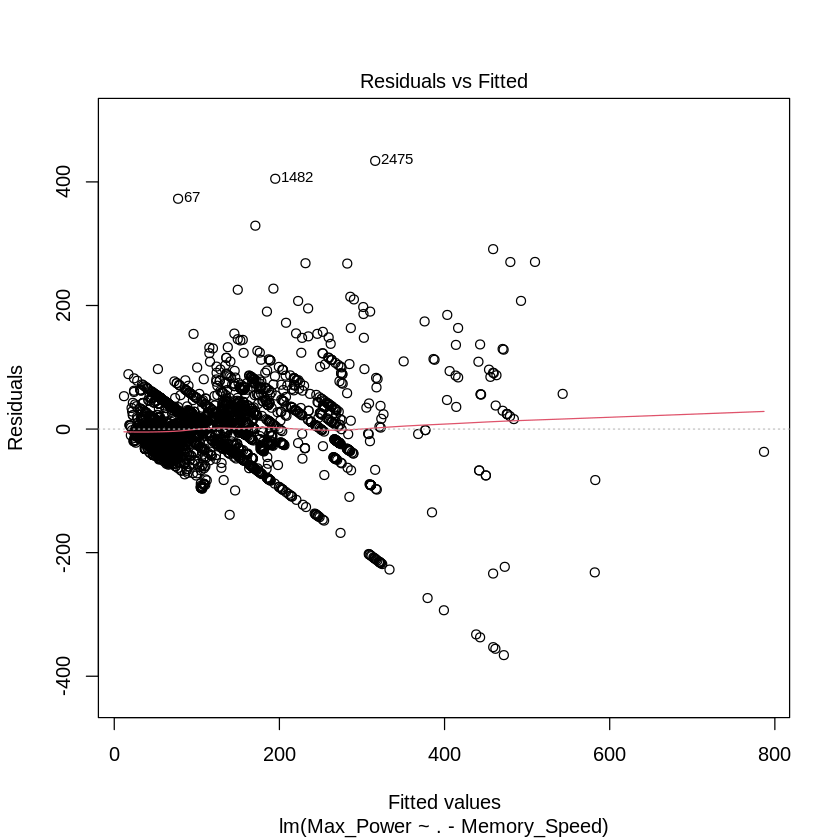

In [240]:
plot(main_model, which = 1)

Tính tuyến tính của mô hình có thể được chấp nhận khi trung bình của phần dư tại mỗi giá trị dự đoán - được thể hiện bởi đường màu đỏ - xấp xỉ 0. Ở biểu đồ này, đường màu đỏ cho ta thấy trung bình của các phần dư tương đối ổn định xung quanh đường y = 0 và có xu hướng hơi lệch ra xa y = 0 khi giá trị dự báo tăng lên, các điểm dữ liệu cũng thưa dần. Điều này gợi ý rằng sự chênh lệch này là không quá đáng kể và chủ yếu là do thiếu dữ liệu ở các giá trị dự báo lớn, do đó ta xem như giả định tuyến tính được thoả.

Giả định về phương sai hằng của sai số cũng có thể được đánh giá qua biểu đồ này. Có thể nhận thấy rằng khi các giá trị dự báo tăng lên, phân bố của các giá trị phần dư có xu hướng loe rộng ra (hình cái phễu). Điều này làm cho mô hình bị vi phạm giả định về phương sai hằng. Ta có thể kiểm tra kỹ hơn giả định về phương sai hằng bằng kiểm định Breusch-Pagan:

- $H_0$: các sai số có phương sai hằng.
- $H_1$: các sai số có phương sai thay đổi.

In [241]:
library(lmtest)
bptest(main_model)


	studentized Breusch-Pagan test

data:  main_model
BP = 741.07, df = 7, p-value < 2.2e-16


Với mức ý nghĩa 5%, ta có thể bác bỏ $H_0$, phù hợp với nhận định trước đó khi đánh giá biểu đồ Residual vs Fitted.

Tiếp theo, để kiểm tra giả định về phân phối chuẩn của sai số với giá trị kỳ vọng bằng 0, ta có thể đánh giá biểu đồ quantile-quantile (Q-Q plot), nếu các điểm dữ liệu nằm sát đường nét đứt, giả định về phân phối chuẩn của sai số có thể xem như thoả mãn:

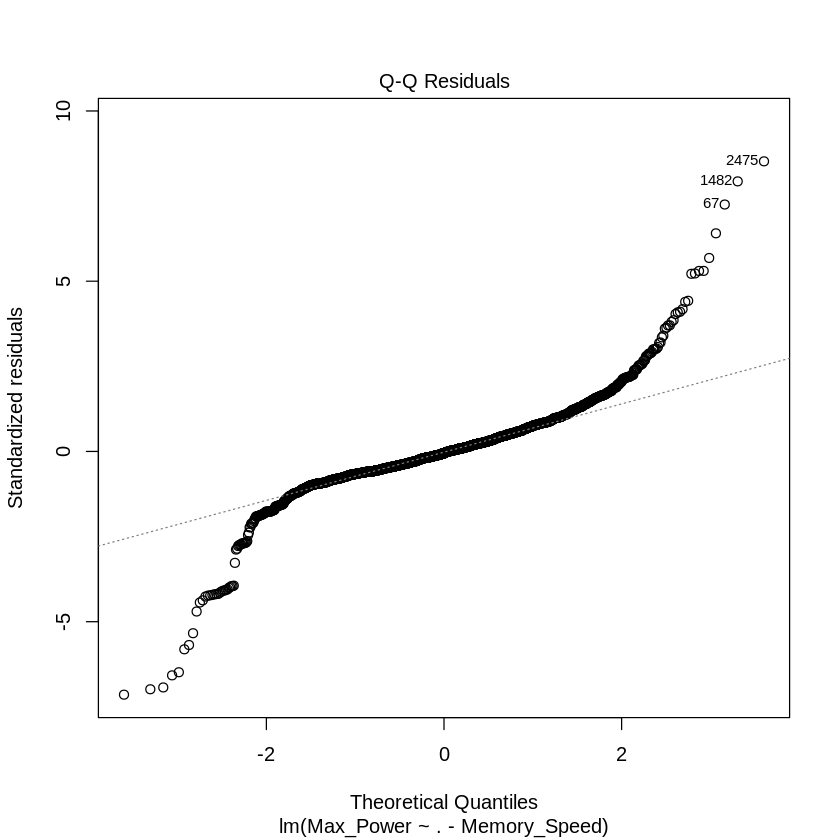

In [242]:
plot(main_model, which = 2)

Ở biểu đồ này, các điểm dữ liệu trong khoảng $Z_{score}$ từ -2 đến 2 đều nằm sát đường nét đứt, tuy nhiên khi đi về 2 phía theo trục x, các điểm dữ liệu càng đi xa đường nét đứt, và đối xứng qua đường nét đứt.
Điều này thể hiện rằng, mật độ giá trị sai số giao động quanh giá trị 0 cao hơn so với theo phân phối chuẩn, khiến cho phân phối của sai số có dạng chuông nhọn, đuôi nặng.

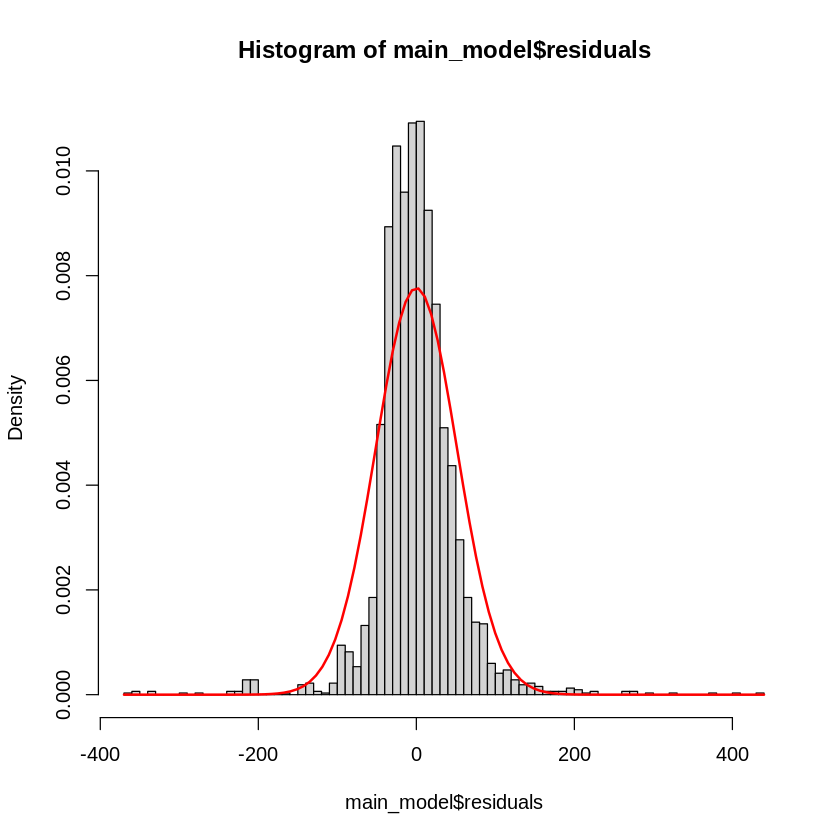

In [243]:
hist(main_model$residuals, breaks = 80, freq = FALSE)
m <- mean(main_model$residuals)
std <- sd(main_model$residuals)
curve(dnorm(x, mean = m, sd = std), col = "red", lwd = 2, add = TRUE)

Đến đây, ta dường như đã có thể kết luận rằng giả định về phân phối chuẩn cũng đã bị vi phạm. Tuy nhiên ta có thể kiểm tra một cách chính quy hơn bằng kiểm định Shapiro-Wilk:
- $H_0$: phân phối của sai số là phân phối chuẩn.
- $H_1$: phân phối của sai số không tuân theo phân phối chuẩn.

In [244]:
set.seed(42)
shapiro.test(main_model$residuals)


	Shapiro-Wilk normality test

data:  main_model$residuals
W = 0.87065, p-value < 2.2e-16


In [245]:
unique(gpu_clean$Memory_Type)

[1] "GDDR3"  "GDDR4"  "GDDR5"  "DDR3"   "DDR4"   "GDDR5X" "HBM-2"  "DDR2"  
 [9] "eDRAM"  "HBM-1"  "GDDR2"

Với mức ý nghĩa 5%, kiểm định trên cũng bác bỏ $H_0$. Phù hợp với nhận định của ta khi đánh giá Q-Q plot.

## 3. Đánh giá mô hình
Mặc dù mô hình vi phạm một số giả định cơ bản về hồi quy tuyến tính, ta vẫn sẽ tiến hành đánh giá độ phù hợp và ý nghĩa thống kê của mô hình.

In [246]:
summary(main_model)


Call:
lm(formula = Max_Power ~ . - Memory_Speed, data = gpu_filter)

Residuals:
    Min      1Q  Median      3Q     Max 
-365.82  -25.64   -2.81   23.49  434.01 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)      35.8735477  5.3189226   6.745 1.82e-11 ***
Core_Speed       -0.0295304  0.0045211  -6.532 7.55e-11 ***
Memory           -0.0063267  0.0005966 -10.604  < 2e-16 ***
Memory_Bandwidth  0.5619795  0.0175908  31.947  < 2e-16 ***
Memory_Bus       -0.0284374  0.0042966  -6.619 4.24e-11 ***
Process           0.7702135  0.0824704   9.339  < 2e-16 ***
ROPs              0.5519192  0.0727075   7.591 4.15e-14 ***
TMUs              0.2977042  0.0307194   9.691  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 51.43 on 3171 degrees of freedom
Multiple R-squared:  0.7109,	Adjusted R-squared:  0.7103 
F-statistic:  1114 on 7 and 3171 DF,  p-value: < 2.2e-16


- Kiểm định hệ số hồi quy của từng biến, mức ý nghĩa 5%:
  - $H_0$: $\beta_i = 0$
  - $H_1$: $\beta_i ≠ 0$
Kết quả được hiển thị ở bảng Coefficients, cột Pr(>|t|). $p-value_i$ < 0.05 với mọi i. Ta kết luận các biến đều có ý nghĩa thống kê đối với mô hình.
- Sai số chuẩn của phần dư (Residual standard error): $\sigma = 51.43$ trên 3171 bậc tự do. Ước lượng của mô hình lệch khoảng 51.43W so với thực tế.
- Hệ số xác định (Multiple R-squared): 0.7109. Các biến đầu vào giải thích được khoảng 71.09% biến thiên dữ liệu.
- Kiểm định hồi quy tổng thể (F-statistics):
  - $H_0$: $\beta_1 = \beta_2 = ... = \beta_7 = 0$
  - $H_1$: có ít nhất một hệ số $\beta_i ≠ 0$ với $ 1 ≤ i ≤ 7$

  Kết quả: $F = 1114$, p-value < $2.2 \cdot 10^{-16}$

  Nếu ta chọn mức ý nghĩa 5%, kết quả trên đã bác bỏ giả thuyết Không, do đó kết luận mô hình có ý nghĩa thống kê.